
## Taller

1. Definir una(s) clase objetivo del conjunto de datos Caltech 256
2. Etiquetar un conjunto de datos para segmentación usando SAM para la clase objetivo


## librerias y setup

In [1]:
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib.patches import Rectangle
import json
from pycocotools import mask as mask_utils
from tqdm import tqdm

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys


PyTorch version: 2.7.1
Torchvision version: 0.22.1
CUDA is available: False


In [2]:
from segment_anything import sam_model_registry, SamPredictor



## 1. Definir una clase objetivo del conjunto de datos Caltech 256

In [3]:
selected_class = '251.airplanes-101'
class_base_path = f'256_ObjectCategories/{selected_class}'
class_list_images = os.listdir(class_base_path)
print(f"Total de imágenes en {selected_class}: {len(class_list_images)}")


Total de imágenes en 251.airplanes-101: 800


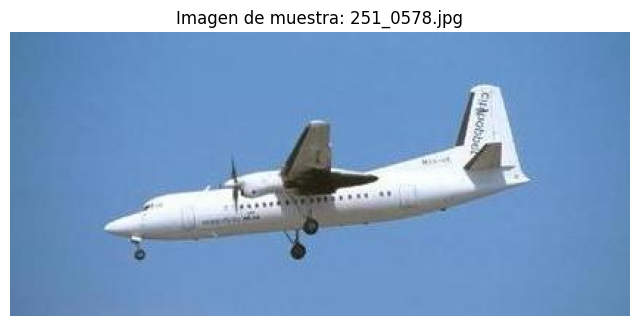

In [4]:
# Visualizar una imagen de muestra
random_index = np.random.randint(0, len(class_list_images))
image_path = os.path.join(class_base_path, class_list_images[random_index])
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis('off')
plt.title(f"Imagen de muestra: {class_list_images[random_index]}")
plt.show()



## 2. Etiquetar un conjunto de datos para segmentación usando SAM para la clase objetivo

### Cargar modelo

In [5]:
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

# Detectar el mejor dispositivo disponible
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"  # Usar CPU en macOS (MPS no es compatible con SAM)

print(f"Usando dispositivo: {device}")

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

# Crear predictor
predictor = SamPredictor(sam)
print("✅ Modelo SAM cargado correctamente")


Usando dispositivo: cpu
✅ Modelo SAM cargado correctamente


### Funciones auxiliares


In [6]:
def generate_center_bbox(image, bbox_ratio=0.7):
    """
    Genera un bounding box centrado en la imagen para usar como prompt.
    
    Args:
        image: Imagen numpy array (H, W, 3)
        bbox_ratio: Ratio del tamaño del bbox respecto a la imagen (0.7 = 70% del tamaño)
    
    Returns:
        bbox: Array [x_min, y_min, x_max, y_max]
    """
    h, w = image.shape[:2]
    
    # Calcular región central
    center_x, center_y = w // 2, h // 2
    bbox_w = int(w * bbox_ratio)
    bbox_h = int(h * bbox_ratio)
    
    x_min = max(0, center_x - bbox_w // 2)
    y_min = max(0, center_y - bbox_h // 2)
    x_max = min(w, center_x + bbox_w // 2)
    y_max = min(h, center_y + bbox_h // 2)
    
    return np.array([x_min, y_min, x_max, y_max])

def generate_points_with_negatives(image, num_positive=9, region_ratio=0.3):
    """
    Genera puntos positivos en la región central y puntos negativos en las esquinas.
    
    Args:
        image: Imagen numpy array (H, W, 3)
        num_positive: Número de puntos positivos (debe ser cuadrado perfecto)
        region_ratio: Ratio de la región central para puntos positivos
    
    Returns:
        points: Array de puntos (N, 2) en formato [x, y]
        labels: Array de labels (N,) donde 1=positivo, 0=negativo
    """
    h, w = image.shape[:2]
    
    # Puntos positivos en el centro
    center_x, center_y = w // 2, h // 2
    region_w = int(w * region_ratio)
    region_h = int(h * region_ratio)
    
    grid_size = int(np.sqrt(num_positive))
    points = []
    labels = []
    
    # Generar puntos positivos
    for i in range(grid_size):
        for j in range(grid_size):
            x = center_x - region_w // 2 + (j * region_w // (grid_size - 1)) if grid_size > 1 else center_x
            y = center_y - region_h // 2 + (i * region_h // (grid_size - 1)) if grid_size > 1 else center_y
            x = np.clip(x, 0, w - 1)
            y = np.clip(y, 0, h - 1)
            points.append([x, y])
            labels.append(1)  # Positivo
    
    # Puntos negativos en las esquinas (para excluir el fondo)
    corner_margin = min(w, h) // 10  # Margen desde las esquinas
    negative_points = [
        [corner_margin, corner_margin],  # Esquina superior izquierda
        [w - corner_margin, corner_margin],  # Esquina superior derecha
        [corner_margin, h - corner_margin],  # Esquina inferior izquierda
        [w - corner_margin, h - corner_margin],  # Esquina inferior derecha
    ]
    
    for point in negative_points:
        points.append(point)
        labels.append(0)  # Negativo (background)
    
    return np.array(points), np.array(labels)


# Definir funciones de segmentación
def select_best_mask(masks, scores, image_shape, min_area_ratio=0.1, max_area_ratio=0.9):
    """
    Selecciona la mejor máscara considerando score, área y posición.
    
    Args:
        masks: Lista de máscaras (bool arrays)
        scores: Lista de scores
        image_shape: (H, W) de la imagen
        min_area_ratio: Área mínima relativa (filtrar máscaras muy pequeñas)
        max_area_ratio: Área máxima relativa (filtrar máscaras que cubren toda la imagen)
    
    Returns:
        best_mask: Mejor máscara seleccionada
        best_score: Score de la mejor máscara
        best_idx: Índice de la mejor máscara
    """
    h, w = image_shape[:2]
    total_area = h * w
    min_area = total_area * min_area_ratio
    max_area = total_area * max_area_ratio
    
    # Calcular áreas de todas las máscaras
    mask_areas = [np.sum(mask) for mask in masks]
    
    # Filtrar máscaras por área razonable
    valid_indices = []
    for i, area in enumerate(mask_areas):
        if min_area <= area <= max_area:
            valid_indices.append(i)
    
    if len(valid_indices) == 0:
        # Si ninguna cumple, usar todas
        valid_indices = list(range(len(masks)))
    
    # Seleccionar la máscara con mejor score entre las válidas
    best_idx = valid_indices[np.argmax([scores[i] for i in valid_indices])]
    
    return masks[best_idx], scores[best_idx], best_idx

def segment_image_with_predictor(predictor, image, strategy='bbox', bbox_ratio=0.7, num_points=9):
    """
    Segmenta una imagen usando SAM Predictor con diferentes estrategias.
    
    Args:
        predictor: Instancia de SamPredictor
        image: Imagen numpy array (H, W, 3)
        strategy: 'bbox' (bounding box) o 'combined' (bbox + puntos negativos)
        bbox_ratio: Ratio del bbox (0.7 = 70% del tamaño de la imagen)
        num_points: Número de puntos negativos si strategy='combined'
    
    Returns:
        mask: Máscara binaria (H, W) o None si falla
        score: Score de la máscara o None si falla
    """
    try:
        h, w = image.shape[:2]
        predictor.set_image(image)
        
        if strategy == 'bbox':
            # Estrategia 1: Solo bounding box (más efectivo para objetos completos)
            bbox = generate_center_bbox(image, bbox_ratio=bbox_ratio)
            masks, scores, logits = predictor.predict(
                box=bbox[None, :],  # Formato: [x_min, y_min, x_max, y_max]
                multimask_output=True
            )
            
        elif strategy == 'combined':
            # Estrategia 2: Bounding box + puntos negativos (más robusto)
            bbox = generate_center_bbox(image, bbox_ratio=bbox_ratio)
            points, labels = generate_points_with_negatives(image, num_positive=num_points, region_ratio=0.3)
            # Combinar: bbox para el objeto y puntos negativos para excluir fondo
            masks, scores, logits = predictor.predict(
                box=bbox[None, :],
                point_coords=points[labels == 0],  # Solo puntos negativos
                point_labels=labels[labels == 0],
                multimask_output=True
            )
        else:
            raise ValueError(f"Estrategia desconocida: {strategy}")
        
        # Seleccionar mejor máscara considerando área y score
        best_mask, best_score, best_idx = select_best_mask(masks, scores, (h, w))
        
        return best_mask, best_score
        
    except Exception as e:
        print(f"Error en segmentación: {e}")
        return None, None


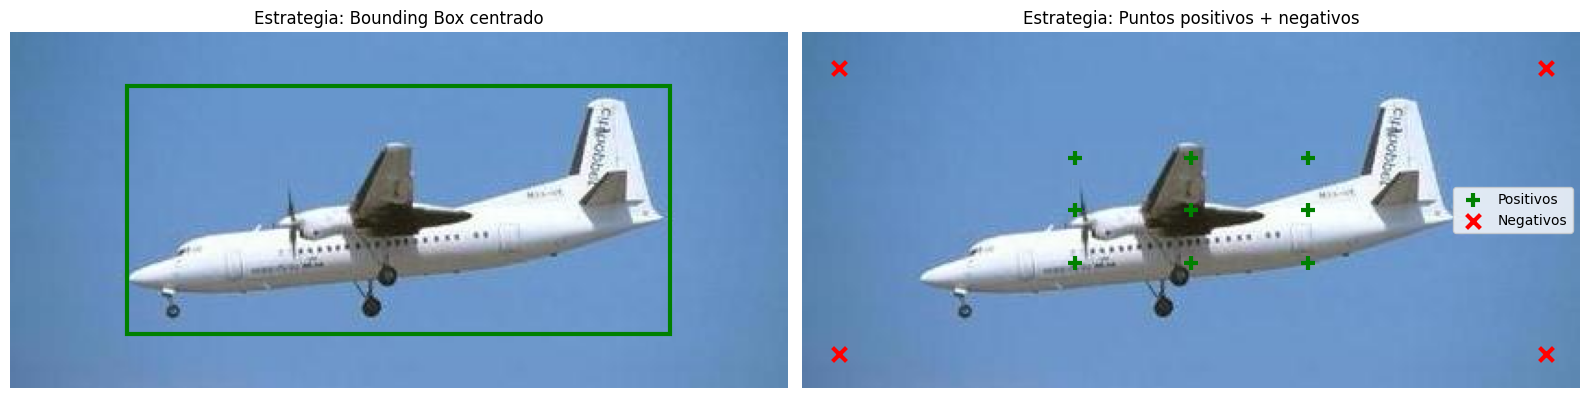

Bounding box: [ 63  29 357 163]
Puntos totales: 13 (positivos: 9, negativos: 4)


In [7]:
# Visualizar estrategias
test_image = cv2.imread(image_path)
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Bounding box
bbox = generate_center_bbox(test_image, bbox_ratio=0.7)
axes[0].imshow(test_image)
rect = Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
                 linewidth=3, edgecolor='green', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title("Estrategia: Bounding Box centrado")
axes[0].axis('off')

# Puntos con negativos
points, labels = generate_points_with_negatives(test_image, num_positive=9, region_ratio=0.3)
positive_points = points[labels == 1]
negative_points = points[labels == 0]
axes[1].imshow(test_image)
axes[1].scatter(positive_points[:, 0], positive_points[:, 1], c='green', s=100, marker='+', linewidths=3, label='Positivos')
axes[1].scatter(negative_points[:, 0], negative_points[:, 1], c='red', s=100, marker='x', linewidths=3, label='Negativos')
axes[1].set_title("Estrategia: Puntos positivos + negativos")
axes[1].legend()
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Bounding box: {bbox}")
print(f"Puntos totales: {len(points)} (positivos: {np.sum(labels)}, negativos: {np.sum(1-labels)})")

### Ejemplo segmentacion una imagen


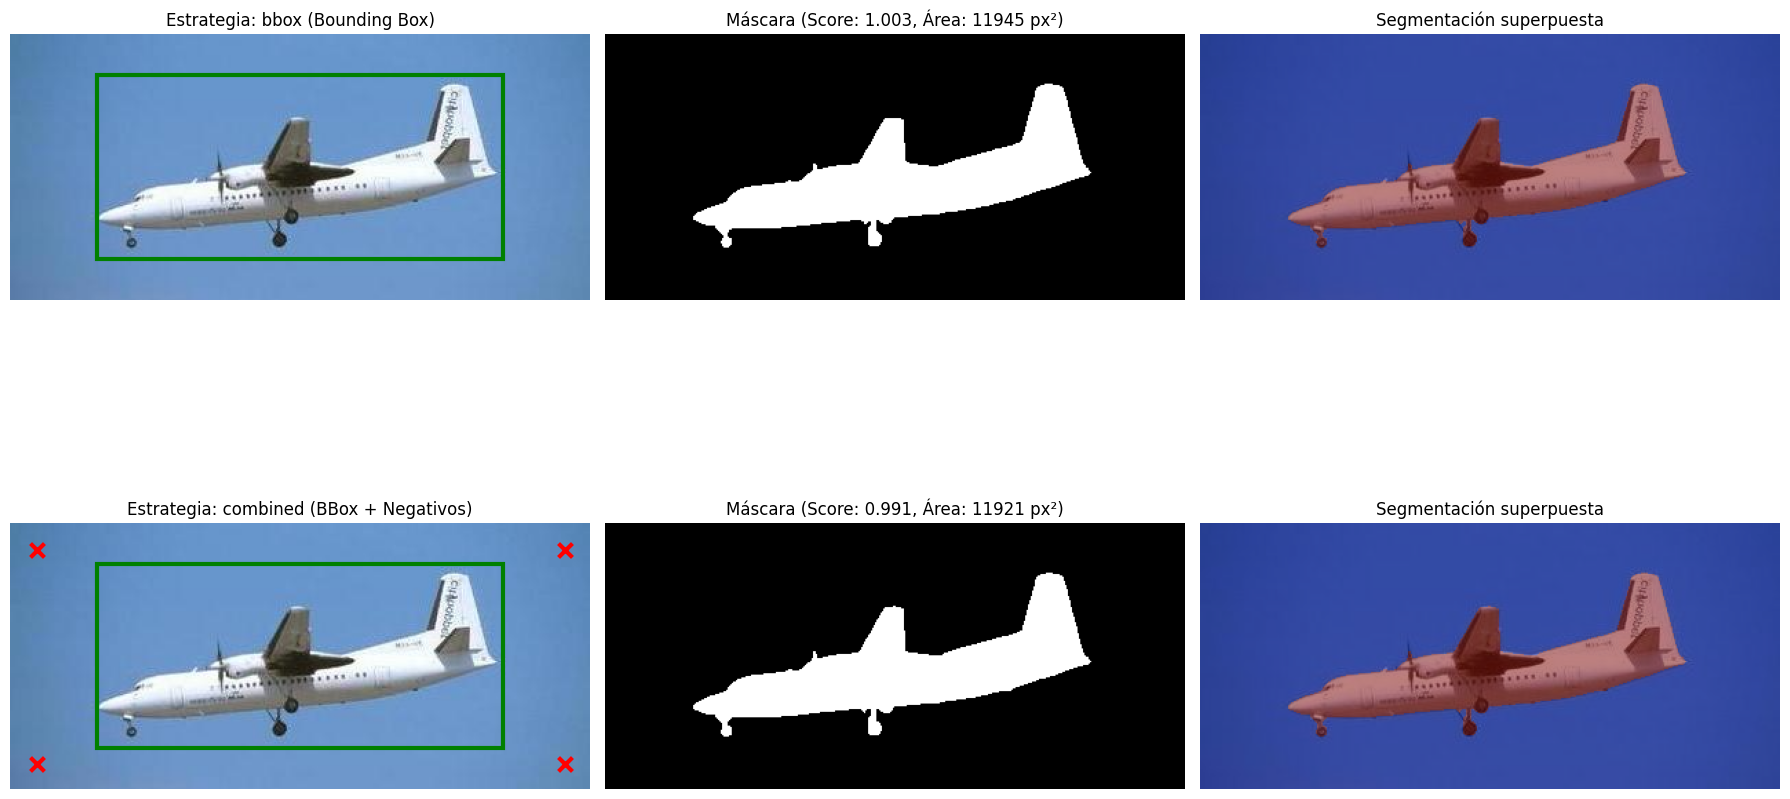

✅ Comparación de estrategias completada


In [8]:
# Probar diferentes estrategias en una imagen de ejemplo
example_image = cv2.imread(image_path)
example_image = cv2.cvtColor(example_image, cv2.COLOR_BGR2RGB)

strategies_to_test = ['bbox', 'combined']
fig, axes = plt.subplots(len(strategies_to_test), 3, figsize=(18, 6 * len(strategies_to_test)))

for idx, strategy in enumerate(strategies_to_test):
    # Segmentar
    mask, score = segment_image_with_predictor(
        predictor, 
        example_image, 
        strategy=strategy,
        bbox_ratio=0.7,
        num_points=9
    )
    
    if mask is None:
        continue
    
    # Visualizar resultado
    # Imagen original con prompt
    axes[idx, 0].imshow(example_image)
    if strategy == 'bbox':
        bbox = generate_center_bbox(example_image, bbox_ratio=0.7)
        rect = Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
                         linewidth=3, edgecolor='green', facecolor='none')
        axes[idx, 0].add_patch(rect)
        axes[idx, 0].set_title(f"Estrategia: {strategy} (Bounding Box)")
    else:
        # Estrategia combined: bbox + puntos negativos
        bbox = generate_center_bbox(example_image, bbox_ratio=0.7)
        points, labels = generate_points_with_negatives(example_image, num_positive=9, region_ratio=0.3)
        neg_points = points[labels == 0]
        rect = Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
                         linewidth=3, edgecolor='green', facecolor='none')
        axes[idx, 0].add_patch(rect)
        axes[idx, 0].scatter(neg_points[:, 0], neg_points[:, 1], c='red', s=100, marker='x', linewidths=3)
        axes[idx, 0].set_title(f"Estrategia: {strategy} (BBox + Negativos)")
    axes[idx, 0].axis('off')
    
    # Máscara
    axes[idx, 1].imshow(mask, cmap='gray')
    axes[idx, 1].set_title(f"Máscara (Score: {score:.3f}, Área: {np.sum(mask):.0f} px²)")
    axes[idx, 1].axis('off')
    
    # Imagen con máscara superpuesta
    axes[idx, 2].imshow(example_image)
    axes[idx, 2].imshow(mask, alpha=0.5, cmap='jet')
    axes[idx, 2].set_title("Segmentación superpuesta")
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

print("✅ Comparación de estrategias completada")



## 2.1. Procesar todas las imágenes de la clase objetivo y generar máscaras


In [9]:
def encode_mask_to_rle(mask):
    """Convierte una máscara binaria a formato RLE de COCO"""
    rle = mask_utils.encode(np.asfortranarray(mask.astype(np.uint8)))
    
    # Asegurar que 'counts' sea siempre un string (JSON serializable)
    if isinstance(rle['counts'], bytes):
        rle['counts'] = rle['counts'].decode('utf-8')
    elif not isinstance(rle['counts'], str):
        rle['counts'] = str(rle['counts'])
    
    # Convertir el diccionario RLE a un diccionario Python estándar
    rle_dict = {
        'size': list(rle['size']),
        'counts': rle['counts']
    }
    return rle_dict



In [10]:
# Configuración de procesamiento
SEGMENTATION_STRATEGY = 'bbox'  # Opciones: 'bbox', 'combined'
BBOX_RATIO = 0.7  # Ratio del bounding box (0.7 = 70% del tamaño de la imagen)
NUM_POINTS = 9  # Número de puntos negativos si strategy='combined' (se usan 4 puntos negativos en esquinas)
NUM_IMAGES_TO_PROCESS = 100  # Cambiar a len(class_list_images) para procesar todas

# Directorio donde guardaremos las anotaciones
annotations_dir = f"annotations_{selected_class.replace('/', '_')}_predictor_{SEGMENTATION_STRATEGY}"
os.makedirs(annotations_dir, exist_ok=True)

print(f"Procesando imágenes de la clase: {selected_class}")
print(f"Total de imágenes disponibles: {len(class_list_images)}")
print(f"Imágenes a procesar: {NUM_IMAGES_TO_PROCESS}")
print(f"Estrategia de segmentación: {SEGMENTATION_STRATEGY}")
print(f"  - Bounding box ratio: {BBOX_RATIO}")
if SEGMENTATION_STRATEGY == 'combined':
    print(f"  - Usando puntos negativos en esquinas para excluir fondo")
print(f"Las anotaciones se guardarán en: {annotations_dir}")


Procesando imágenes de la clase: 251.airplanes-101
Total de imágenes disponibles: 800
Imágenes a procesar: 100
Estrategia de segmentación: bbox
  - Bounding box ratio: 0.7
Las anotaciones se guardarán en: annotations_251.airplanes-101_predictor_bbox


In [11]:
# Procesar todas las imágenes
annotations_data = {
    "info": {
        "description": f"Segmentación de objetos para clase {selected_class} usando SAM Predictor",
        "class": selected_class,
        "strategy": SEGMENTATION_STRATEGY,
        "bbox_ratio": BBOX_RATIO,
        "num_points": NUM_POINTS if SEGMENTATION_STRATEGY == 'combined' else None
    },
    "images": [],
    "annotations": []
}

annotation_id = 0
failed_images = []

# Procesar cada imagen
for idx, image_filename in enumerate(tqdm(class_list_images[:NUM_IMAGES_TO_PROCESS], desc="Procesando imágenes")):
    if not image_filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
        continue
    
    image_path = os.path.join(class_base_path, image_filename)
    
    try:
        # Cargar imagen
        image = cv2.imread(image_path)
        if image is None:
            print(f"Advertencia: No se pudo cargar {image_filename}")
            failed_images.append(image_filename)
            continue
        
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image_rgb.shape[:2]
        
        # Segmentar imagen usando SAM Predictor
        mask, score = segment_image_with_predictor(
            predictor, 
            image_rgb, 
            strategy=SEGMENTATION_STRATEGY,
            bbox_ratio=BBOX_RATIO,
            num_points=NUM_POINTS
        )
        
        if mask is None or score is None:
            print(f"Advertencia: No se generó máscara para {image_filename}")
            failed_images.append(image_filename)
            continue
        
        # Convertir máscara a binaria (por si acaso)
        mask_binary = mask.astype(np.uint8)
        
        # Crear entrada de imagen
        image_info = {
            "id": idx,
            "file_name": image_filename,
            "width": w,
            "height": h,
            "path": image_path
        }
        annotations_data["images"].append(image_info)
        
        # Convertir máscara a RLE
        rle = encode_mask_to_rle(mask_binary)
        
        # Calcular bbox de la máscara (formato XYWH)
        rows = np.any(mask_binary, axis=1)
        cols = np.any(mask_binary, axis=0)
        if np.any(rows) and np.any(cols):
            y_min, y_max = np.where(rows)[0][[0, -1]]
            x_min, x_max = np.where(cols)[0][[0, -1]]
            bbox = [int(x_min), int(y_min), int(x_max - x_min + 1), int(y_max - y_min + 1)]
        else:
            bbox = [0, 0, w, h]  # Fallback
        
        # Crear anotación
        annotation = {
            "id": annotation_id,
            "image_id": idx,
            "category_id": 1,  # Clase objetivo
            "segmentation": rle,
            "bbox": bbox,
            "area": int(np.sum(mask_binary)),
            "score": float(score)
        }
        annotations_data["annotations"].append(annotation)
        annotation_id += 1
        
    except Exception as e:
        print(f"Error procesando {image_filename}: {e}")
        failed_images.append(image_filename)
        continue

print(f"\n✅ Procesamiento completado:")
print(f"   - Imágenes procesadas exitosamente: {len(annotations_data['images'])}")
print(f"   - Anotaciones generadas: {len(annotations_data['annotations'])}")
if failed_images:
    print(f"   - Imágenes fallidas: {len(failed_images)}")


Procesando imágenes: 100%|██████████| 100/100 [14:34<00:00,  8.74s/it]


✅ Procesamiento completado:
   - Imágenes procesadas exitosamente: 100
   - Anotaciones generadas: 100


In [12]:
def clean_for_json(obj):
    """Función recursiva para limpiar objetos y asegurar que sean JSON serializables"""
    if isinstance(obj, dict):
        return {key: clean_for_json(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [clean_for_json(item) for item in obj]
    elif isinstance(obj, (np.ndarray, np.integer, np.floating)):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return obj.item() if hasattr(obj, 'item') else float(obj) if isinstance(obj, np.floating) else int(obj)
    elif isinstance(obj, bytes):
        return obj.decode('utf-8')
    elif isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    elif isinstance(obj, (int, float, str, type(None))):
        return obj
    else:
        return str(obj)

# Limpiar los datos antes de guardar en JSON
annotations_data_clean = clean_for_json(annotations_data)

# Guardar anotaciones en formato JSON
annotations_file = os.path.join(annotations_dir, "annotations.json")
with open(annotations_file, 'w') as f:
    json.dump(annotations_data_clean, f, indent=2, ensure_ascii=False)

print(f"✅ Anotaciones guardadas en: {annotations_file}")


✅ Anotaciones guardadas en: annotations_251.airplanes-101_predictor_bbox/annotations.json



## 2.2. Visualizar algunas anotaciones generadas

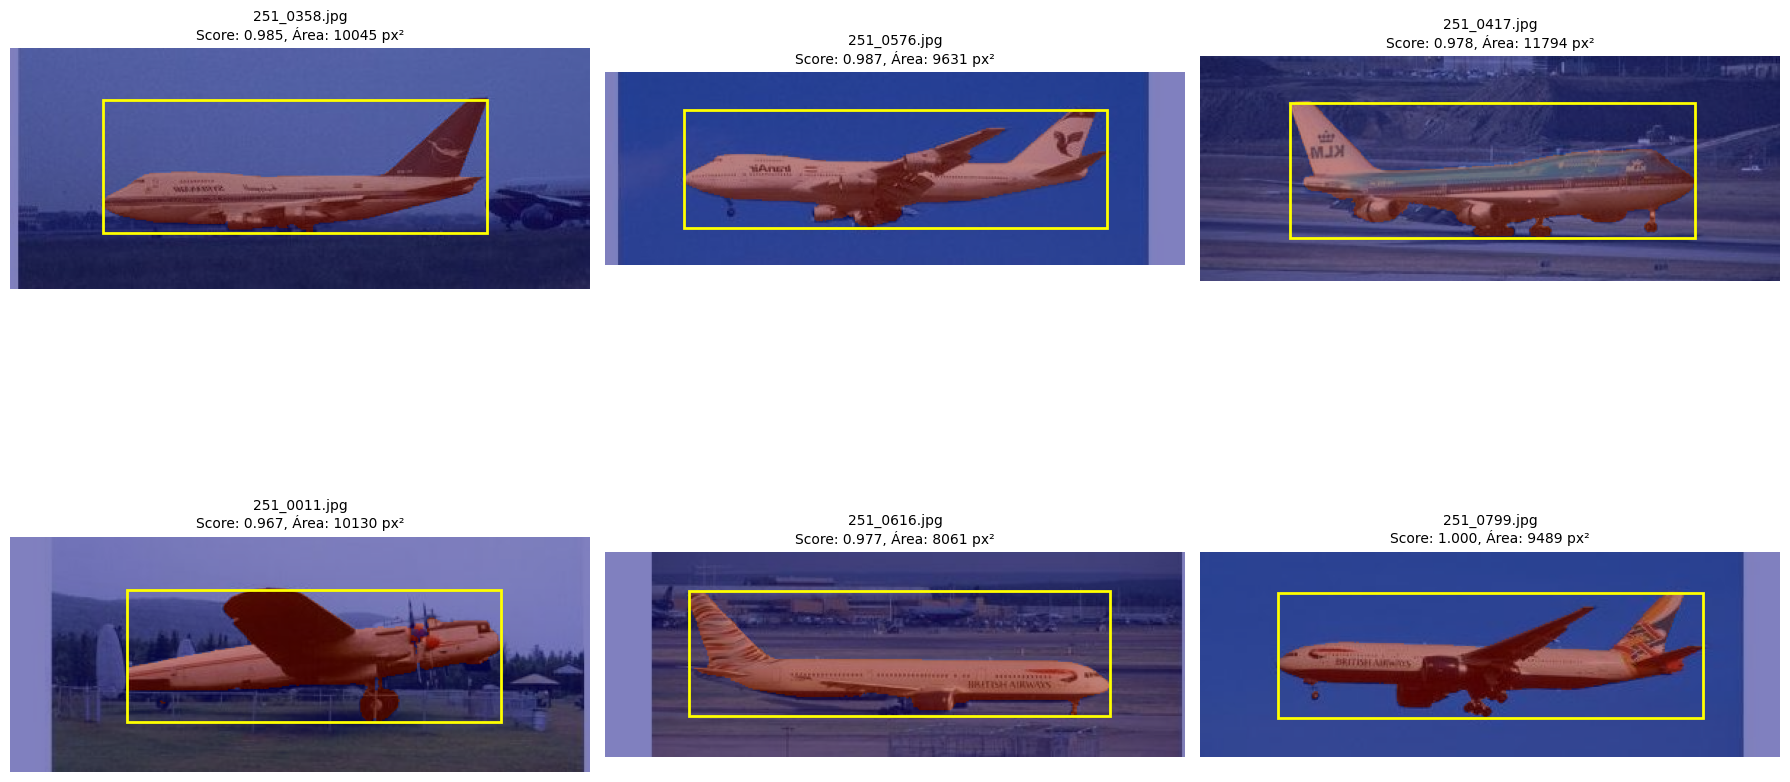

In [13]:
# Visualizar algunas imágenes con sus máscaras generadas
num_samples = min(6, len(annotations_data['images']))
sample_indices = np.linspace(0, len(annotations_data['images']) - 1, num_samples, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, img_idx in enumerate(sample_indices):
    image_info = annotations_data['images'][img_idx]
    annotation = annotations_data['annotations'][img_idx]
    
    # Cargar imagen
    image = cv2.imread(image_info['path'])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Decodificar máscara
    rle = annotation['segmentation'].copy()
    
    # Asegurar que 'counts' sea bytes (necesario para mask_utils.decode)
    if isinstance(rle['counts'], str):
        rle['counts'] = rle['counts'].encode('utf-8')
    elif not isinstance(rle['counts'], bytes):
        rle['counts'] = str(rle['counts']).encode('utf-8')
    
    mask = mask_utils.decode(rle)
    
    # Mostrar imagen con máscara
    axes[idx].imshow(image)
    axes[idx].imshow(mask, alpha=0.5, cmap='jet')
    
    # Mostrar bbox
    bbox = annotation['bbox']
    rect = Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], 
                     linewidth=2, edgecolor='yellow', facecolor='none')
    axes[idx].add_patch(rect)
    
    axes[idx].set_title(f"{image_info['file_name']}\n"
                       f"Score: {annotation['score']:.3f}, "
                       f"Área: {annotation['area']} px²",
                       fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


## 2.3. Estadísticas del dataset etiquetado



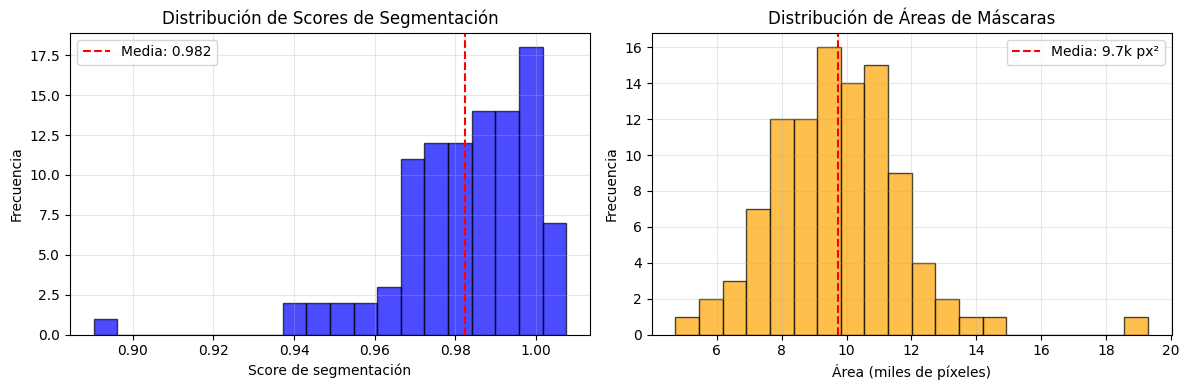


📊 Estadísticas del dataset:
   - Score - Media: 0.982, Std: 0.018
   - Score - Mínimo: 0.890, Máximo: 1.008
   - Área promedio: 9742.5 píxeles²
   - Área mínima: 4731.0 píxeles²
   - Área máxima: 19286.0 píxeles²


In [14]:
# Calcular estadísticas
scores = [ann['score'] for ann in annotations_data['annotations']]
areas = [ann['area'] for ann in annotations_data['annotations']]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de scores
axes[0].hist(scores, bins=20, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_xlabel('Score de segmentación')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Scores de Segmentación')
axes[0].axvline(np.mean(scores), color='red', linestyle='--', 
                label=f'Media: {np.mean(scores):.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma de áreas
axes[1].hist(np.array(areas) / 1000, bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Área (miles de píxeles)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Áreas de Máscaras')
axes[1].axvline(np.mean(areas) / 1000, color='red', linestyle='--',
                label=f'Media: {np.mean(areas)/1000:.1f}k px²')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas del dataset:")
print(f"   - Score - Media: {np.mean(scores):.3f}, Std: {np.std(scores):.3f}")
print(f"   - Score - Mínimo: {np.min(scores):.3f}, Máximo: {np.max(scores):.3f}")
print(f"   - Área promedio: {np.mean(areas):.1f} píxeles²")
print(f"   - Área mínima: {np.min(areas):.1f} píxeles²")
print(f"   - Área máxima: {np.max(areas):.1f} píxeles²")
